In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import plotly.express as px

In [12]:
df = pd.read_csv('HR_comma_sep (1).csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [13]:
df.drop(['last_evaluation', 'Work_accident', 'left', 'promotion_last_5years'], axis=1, inplace=True)

df.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary
0,0.38,2,157,3,sales,low
1,0.80,5,262,6,sales,medium
2,0.11,7,272,4,sales,medium
3,0.72,5,223,5,sales,low
4,0.37,2,159,3,sales,low


In [5]:
df.isnull().sum()

satisfaction_level      0
number_project          0
average_montly_hours    0
time_spend_company      0
Department              0
salary                  0
dtype: int64

In [14]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [15]:
col = df['satisfaction_level']


Q1, Q3 = np.percentile(col, [25, 75])
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(lower_fence)
print(upper_fence)
outliers = [x for x in col if x < lower_fence or x > upper_fence]
print("Outliers:", outliers) 

-0.12999999999999995
1.39
Outliers: []


In [16]:
df['salary'] = df['salary'].map({
    'low': 0,
    'medium': 1,
    'high': 2
})
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary
0,0.38,2,157,3,7,0
1,0.80,5,262,6,7,1
2,0.11,7,272,4,7,1
3,0.72,5,223,5,7,0
4,0.37,2,159,3,7,0


In [17]:
scaler = MinMaxScaler()

df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\n normalized Data:")
print(df_normalized)

df.head()


 normalized Data:
       satisfaction_level  number_project  average_montly_hours  \
0                0.318681             0.0              0.285047   
1                0.780220             0.6              0.775701   
2                0.021978             1.0              0.822430   
3                0.692308             0.6              0.593458   
4                0.307692             0.0              0.294393   
...                   ...             ...                   ...   
14994            0.340659             0.0              0.257009   
14995            0.307692             0.0              0.299065   
14996            0.307692             0.0              0.219626   
14997            0.021978             0.8              0.859813   
14998            0.307692             0.0              0.289720   

       time_spend_company  Department  salary  
0                   0.125    0.777778     0.0  
1                   0.500    0.777778     0.5  
2                   0.250    0.7

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary
0,0.38,2,157,3,7,0
1,0.80,5,262,6,7,1
2,0.11,7,272,4,7,1
3,0.72,5,223,5,7,0
4,0.37,2,159,3,7,0


In [18]:
satisfaction_level_discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df['satisfaction_level_bin'] =satisfaction_level_discretizer.fit_transform(df[['satisfaction_level']])
df.head(35)

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,satisfaction_level_bin
0,0.38,2,157,3,7,0,1.0
1,0.80,5,262,6,7,1,3.0
2,0.11,7,272,4,7,1,0.0
3,0.72,5,223,5,7,0,2.0
4,0.37,2,159,3,7,0,1.0
5,0.41,2,153,3,7,0,1.0
6,0.10,6,247,4,7,0,0.0
7,0.92,5,259,5,7,0,3.0
8,0.89,5,224,5,7,0,3.0
9,0.42,2,142,3,7,0,1.0


In [19]:
df['satisfaction_bin'] = pd.cut(df['satisfaction_level'], bins=3, labels=['Low', 'Medium', 'High'])
df.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,satisfaction_level_bin,satisfaction_bin
0,0.38,2,157,3,7,0,1.0,Low
1,0.80,5,262,6,7,1,3.0,High
2,0.11,7,272,4,7,1,0.0,Low
3,0.72,5,223,5,7,0,2.0,High
4,0.37,2,159,3,7,0,1.0,Low


In [20]:
df.drop('satisfaction_level', axis=1, inplace=True)
df.head()

,number_project,average_montly_hours,time_spend_company,Department,salary,satisfaction_level_bin,satisfaction_bin
0,2,157,3,7,0,1.0,Low
1,5,262,6,7,1,3.0,High
2,7,272,4,7,1,0.0,Low
3,5,223,5,7,0,2.0,High
4,2,159,3,7,0,1.0,Low


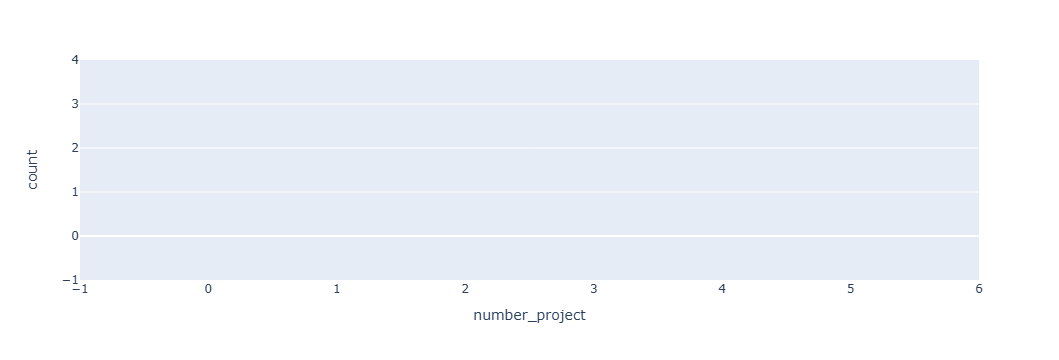

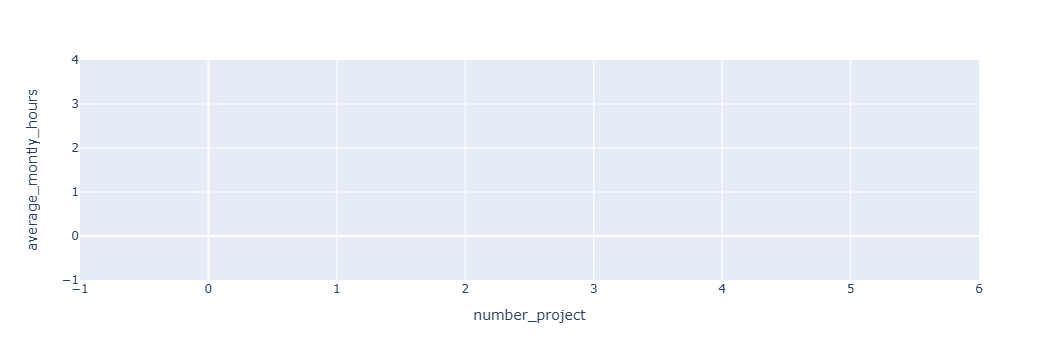

In [21]:
fig = px.histogram(df, x=df.columns[0])
fig.show()

# Scatter plot

fig = px.scatter(df, x=df.columns[0], y=df.columns[1])
fig.show()

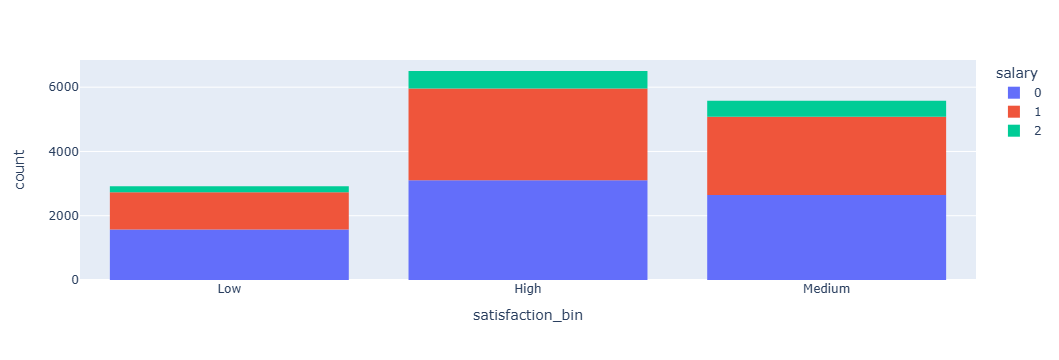

In [29]:
import plotly.express as px

fig = px.histogram(df, x='satisfaction_bin', color='salary')
fig.show()

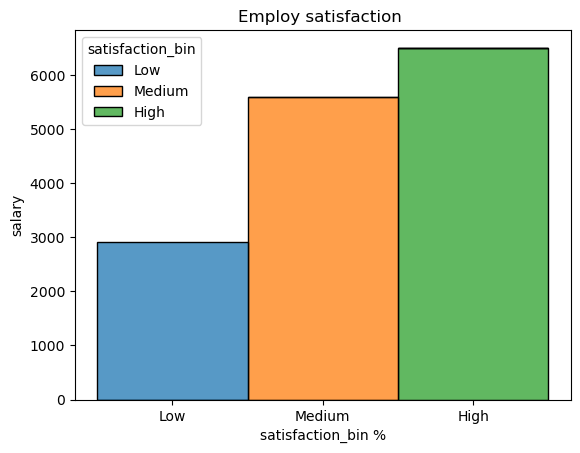

In [30]:
plt.figure()
sns.histplot(data=df,x='satisfaction_bin',hue='satisfaction_bin',multiple='stack')
plt.title("Employ satisfaction ")
plt.xlabel("satisfaction_bin %")
plt.ylabel("salary")
plt.show()